# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
* **The purpose of this Notebook**:
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Input**:
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`
    * `generic_models_functions.py` - helper methods for the models
    * `generic_dataset_functions_ml.py` - helper methods for transforming the dataset

# Imports

In [ ]:
!pip install skrebate

  Preparing metadata (setup.py) ... done
  Created wheel for skrebate: filename=skrebate-0.62-py3-none-any.whl size=29253 sha256=6634b162d9019602652b21379d88ffbb362a7eb57e412ef7cc4ba55283783f91
  Stored in directory: /root/.cache/pip/wheels/03/4c/36/bc6b70d88998635e0ec0e617d15cd97483f5008d6bb77c1c7a
Successfully built skrebate


In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter
import time
from scipy.signal import medfilt
from sklearn.utils.class_weight import compute_sample_weight
from skrebate import ReliefF
import sys

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

In [ ]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data'
helper_functions_path = base_path + '/helper_functions'

Mounted at /content/drive


In [ ]:
sys.path.append(helper_functions_path)

import generic_dataset_functions_ml as dataset_fct
import generic_models_functions as model_fct

# Datasets

In [ ]:
df_train = pd.read_csv(base_path + '/process_dataset/ml_dataset/train_features.csv')
df_val = pd.read_csv(base_path + '/process_dataset/ml_dataset/val_features.csv')

In [ ]:
X_train = df_train.drop('Label', axis=1)
y_train = df_train['Label']

X_val = df_val.drop('Label', axis=1)
y_val = df_val['Label']

In [ ]:
df_train.head()

,Subject_ID,Dataset_Source,Mean,Std,Skewness,Kurtosis,Zero_Crossings,Mobility,Complexity,Spectral_Entropy,...,Abs_Alpha,Abs_Sigma,Abs_Beta,Abs_Total,Rel_Delta,Rel_Theta,Rel_Alpha,Rel_Sigma,Rel_Beta,Label
0,1,0,-0.429715,50.406050,-26.741851,1125.532264,1153,1.183026,1.331633,4.344991,...,379.917778,352.970003,1291.015457,3872.918762,0.177090,0.124850,0.098096,0.091138,0.333344,0
1,1,0,-0.860650,92.382850,0.635777,8.816965,802,0.116358,12.274820,1.394550,...,24.621977,22.581916,46.442297,9328.269587,0.870715,0.006607,0.002640,0.002421,0.004979,0
2,1,0,1.408013,39.325005,1.371603,9.175044,775,0.143333,9.249867,1.710211,...,23.411200,13.720810,15.159666,1781.254720,0.849699,0.023930,0.013143,0.007703,0.008511,0
3,1,0,0.367535,27.259431,1.709819,17.910265,908,0.192955,7.103479,1.757544,...,15.676385,8.627362,14.673112,1085.139324,0.845470,0.019371,0.014446,0.007950,0.013522,0
4,1,0,-0.572789,15.452458,-0.169122,7.011664,813,0.279101,4.618365,2.513127,...,19.390871,7.220864,10.013620,245.803829,0.709892,0.064260,0.078888,0.029377,0.040738,0


In [ ]:
cols_to_normalize = [
    'Mean', 'Std', 'Skewness', 'Kurtosis', 'Zero_Crossings',
    'Mobility', 'Complexity', 'Spectral_Entropy',
    'Abs_Delta', 'Abs_Theta', 'Abs_Alpha', 'Abs_Sigma', 'Abs_Beta', 'Abs_Total',
    'Rel_Delta', 'Rel_Theta', 'Rel_Alpha', 'Rel_Sigma', 'Rel_Beta'
]

df_train_norm = dataset_fct.normalize_by_subject(df_train, cols_to_normalize)
df_val_norm   = dataset_fct.normalize_by_subject(df_val, cols_to_normalize)
print(f"Shape after: {df_train_norm.shape}")

Shape after: (228213, 22)


## Add only Lag/ Lead

In [ ]:
df_train_raw_basic = dataset_fct.extract_basic_temporal_features(df_train)
df_val_raw_basic   = dataset_fct.extract_basic_temporal_features(df_val)

X_train_raw_basic = df_train_raw_basic.drop(columns=['Label'])
y_train_raw_basic = df_train_raw_basic['Label']
X_val_raw_basic = df_val_raw_basic.drop(columns=['Label'])
y_val_raw_basic = df_val_raw_basic['Label']

## Normalise Z-Score

In [ ]:
cols_to_normalize = [
    'Mean', 'Std', 'Skewness', 'Kurtosis', 'Zero_Crossings',
    'Mobility', 'Complexity', 'Spectral_Entropy',
    'Abs_Delta', 'Abs_Theta', 'Abs_Alpha', 'Abs_Sigma', 'Abs_Beta', 'Abs_Total',
    'Rel_Delta', 'Rel_Theta', 'Rel_Alpha', 'Rel_Sigma', 'Rel_Beta'
]

df_train_norm = dataset_fct.normalize_by_subject(df_train, cols_to_normalize)
df_val_norm = dataset_fct.normalize_by_subject(df_val, cols_to_normalize)
print(f"Shape after: {df_train_norm.shape}")

Shape after: (228213, 22)


## Lag/ Leag + Z-Score

In [ ]:
df_train_norm_basic = dataset_fct.extract_basic_temporal_features(df_train_norm)
df_val_norm_basic   = dataset_fct.extract_basic_temporal_features(df_val_norm)

df_train_norm_basic['Dataset_Source'] = df_train_norm_basic['Dataset_Source'].astype('category')
df_val_norm_basic['Dataset_Source']   = df_val_norm_basic['Dataset_Source'].astype('category')

X_train_norm_basic = df_train_norm_basic.drop(columns=['Label'])
y_train_norm_basic = df_train_norm_basic['Label']
X_val_norm_basic = df_val_norm_basic.drop(columns=['Label'])
y_val_norm_basic = df_val_norm_basic['Label']

## Temporal feature advances + Z-Score

In [ ]:
df_train_norm_enhanced = dataset_fct.extract_enhanced_temporal_features(df_train_norm)
df_val_norm_enhanced   = dataset_fct.extract_enhanced_temporal_features(df_val_norm)

# Aici dăm drop și la Subject_ID/Dataset_Source, fiindcă modelele bazate pe arbori (RF/XGBoost) nu au nevoie de ele direct
cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']

X_train_norm_enhanced = df_train_norm_enhanced.drop(columns=cols_to_drop, errors='ignore')
y_train_norm_enhanced = df_train_norm_enhanced['Label']
X_val_norm_enhanced = df_val_norm_enhanced.drop(columns=cols_to_drop, errors='ignore')
y_val_norm_enhanced = df_val_norm_enhanced['Label']

## ReliefF

In [ ]:
def relief_feature_selection(X, y):
    '''
    ReliefF is a filter-type feature selection method that assigns a score to each feature based on how well it distinguishes between similar
    examples from different classes. It is an extension of the Relief algorithm, performing well on multi-class problems and noisy data.

    Parameters:
      - X (pd.DataFrame): The input features.
      - y (pd.Series): The target variable.

    Returns:
      - list: A list of selected feature names.
    '''
    from sklearn.model_selection import train_test_split

    sample_size = 10000

    # Temporarily drop 'Subject_ID' if it exists, as it's typically an identifier, not a feature for ReliefF.
    X_for_relief = X.drop(columns=['Subject_ID'], errors='ignore')

    if len(X_for_relief) > sample_size:
        X_sample, _, y_sample, _ = train_test_split(
            X_for_relief,
            y,
            train_size=sample_size,
            stratify=y,
            random_state=42
        )
    else:
        # Correct typo: 'x' to 'X_for_relief'
        X_sample = X_for_relief.copy()
        y_sample = y.copy()

    # Ensure 'Dataset_Source' is int type if it exists in X_sample, as it's treated as a feature.
    if 'Dataset_Source' in X_sample.columns:
        X_sample['Dataset_Source'] = X_sample['Dataset_Source'].astype(int)

    fs = ReliefF(n_features_to_select=25, n_neighbors=10, n_jobs=-1)
    fs.fit(X_sample.values, y_sample.values)

    top_features = []
    for feature_name, feature_score in zip(X_sample.columns, fs.feature_importances_):
        top_features.append((feature_name, feature_score))

    top_features = sorted(top_features, key=lambda x: x[1], reverse=True)
    selected_columns = [feat[0] for feat in top_features[:25]]

    print("Best 25 features:")
    for name, score in top_features[:25]:
        print(f"{name}: {score:.4f}")

    # Reconstruct cols_to_keep, including 'Subject_ID' and 'Dataset_Source' only if they were in the original X.
    final_cols_to_keep = []
    if 'Subject_ID' in X.columns:
        final_cols_to_keep.append('Subject_ID')
    if 'Dataset_Source' in X.columns:
        final_cols_to_keep.append('Dataset_Source')

    # Add selected features, avoiding duplicates if 'Dataset_Source' is already added.
    for col in selected_columns:
        if col not in final_cols_to_keep:
            final_cols_to_keep.append(col)

    return final_cols_to_keep

In [ ]:
cols_to_keep = relief_feature_selection(X_train_norm_enhanced, y_train_norm_enhanced)
X_train_relieff_norm_enhanced = X_train_norm_enhanced[cols_to_keep].copy()
X_val_relieff_norm_enhanced = X_val_norm_enhanced[cols_to_keep].copy()

print(f"New shape: {X_train_relieff_norm_enhanced.shape}")

Best 25 features:
Rel_Beta_roll_mean: 0.0196
Rel_Theta_roll_mean: 0.0178
Rel_Delta_roll_mean: 0.0152
Zero_Crossings_roll_mean: 0.0143
Std_roll_mean: 0.0138
Zero_Crossings: 0.0128
Spectral_Entropy_roll_std: 0.0128
Rel_Theta_roll_std: 0.0126
Zero_Crossings_lag1: 0.0125
Rel_Beta_lead2: 0.0124
Rel_Beta_lead1: 0.0124
Rel_Theta: 0.0122
Zero_Crossings_lead2: 0.0121
Rel_Theta_lag1: 0.0121
Rel_Theta_lead1: 0.0118
Abs_Theta_roll_mean: 0.0117
Abs_Alpha_roll_mean: 0.0115
Zero_Crossings_lead1: 0.0114
Zero_Crossings_lag2: 0.0113
Rel_Delta_lead1: 0.0113
Rel_Theta_lead2: 0.0110
Mobility_roll_mean: 0.0110
Rel_Sigma_roll_mean: 0.0107
Rel_Delta: 0.0105
Abs_Total_roll_mean: 0.0105
New shape: (228213, 25)


# Models

## Baseline LightGBM with SMOTE

In [ ]:
print("--- Class distribution before ---")
print(Counter(y_train))

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- Class distribution after ---")
print(Counter(y_train_smote))

--- Class distribution before ---
Counter({2: 87244, 0: 48348, 4: 35368, 3: 31587, 1: 25666})

--- Class distribution after ---
Counter({0: 87244, 1: 87244, 2: 87244, 3: 87244, 4: 87244})


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102847 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5094
[LightGBM] [Info] Number of data points in the train set: 436220, number of used features: 21
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 60.62 seconds

Accuracy 0.6097

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.68      0.83      0.75     10361
          N1       0.30      0.27      0.28      6930
          N2       0.81      0.55      0.66     20785
          N3       0.65      0.78      0.71      6474
         REM       0.42      0.63      0.51      7574

    accuracy                           0

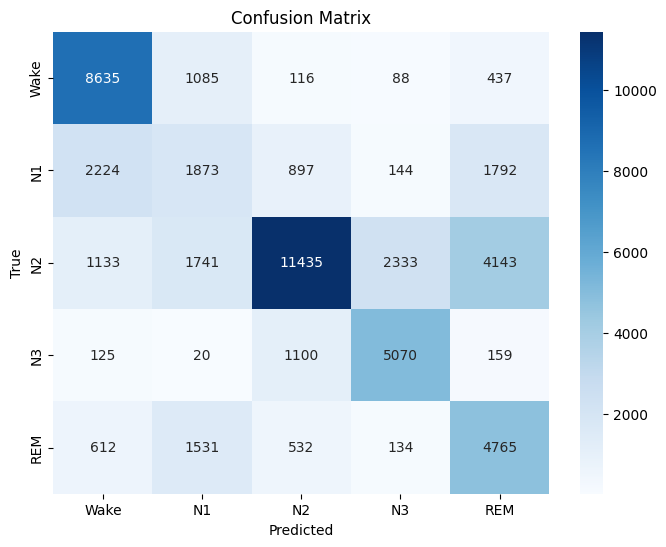

In [ ]:
lgb_smote = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1
)

y_pred_val_lgb_smote = model_fct.train_model(lgb_smote, X_train_smote, y_train_smote, X_val)
model_fct.evaluete_model(y_val, y_pred_val_lgb_smote)

## LightGBM + Lag/Lead + Class Weights

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.265992 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24228
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

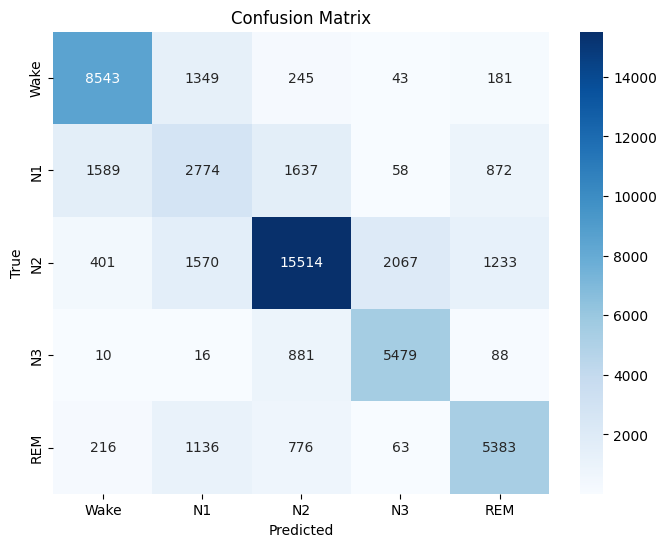

In [ ]:
lgb_lag = lgb.LGBMClassifier(
    n_estimators=500, # trees
    learning_rate=0.05,
    max_depth=10,
    num_leaves=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_lag = model_fct.train_model(lgb_lag, X_train_raw_basic, y_train_raw_basic, X_val_raw_basic)

df_eval = model_fct.create_evaluation_table(y_val_raw_basic, y_pred_lgb_lag,df_val)

model_fct.evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## LightGBM + Z-Score + Lag/ Lead

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.285380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24229
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 393.54 seconds

Accuracy 0.7324

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.81      0.82     10361
          N1       0.43      0.40      0.42      6930
          N2       0.79      0.78      0.79     20785
          N3       0.71      0.80      0.75      6474
         REM       0.73      0.74      0.73      7574

    accuracy                          

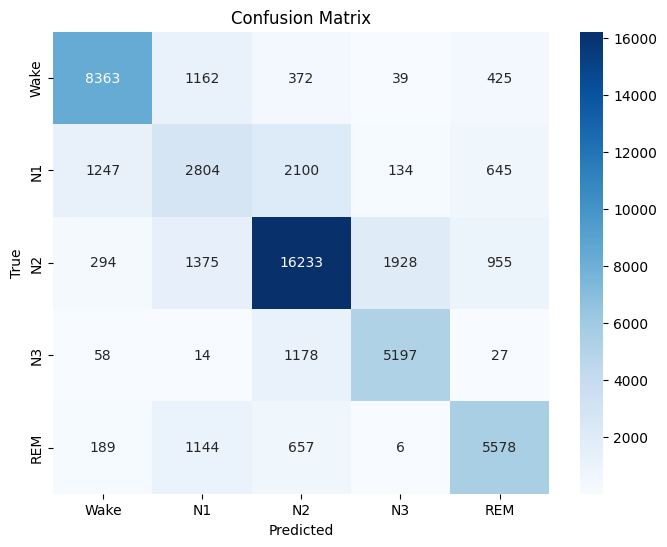

In [ ]:
lgb_zscore = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_zscore = model_fct.train_model(lgb_zscore, X_train_norm_basic, y_train_norm_basic, X_val_norm_basic)

df_eval = model_fct.create_evaluation_table(y_val_norm_basic, y_pred_lgb_zscore,df_val)

model_fct.evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## LightGBM + Advance Temp Context

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.532522 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42840
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 168
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 719.37 seconds

Accuracy 0.7272

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.81      0.81      0.81     10361
          N1       0.43      0.39      0.41      6930
          N2       0.78      0.78      0.78     20785
          N3       0.70      0.79      0.74      6474
         REM       0.73      0.74      0.74      7574

    accuracy                         

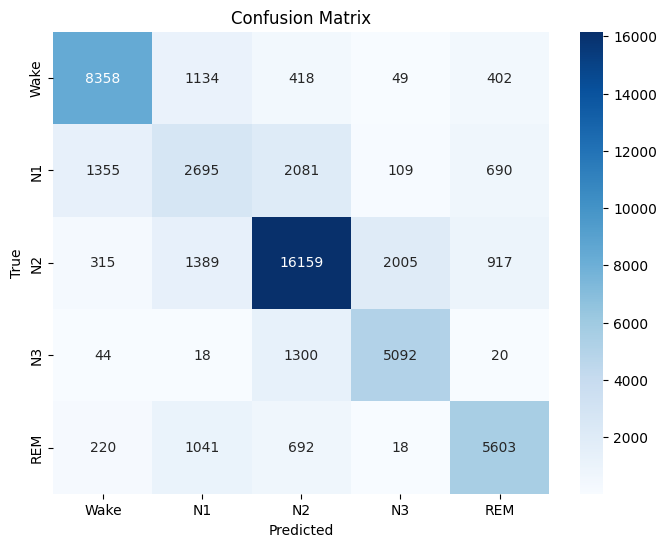

In [ ]:
lgb_norm_enhanced = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_norm_enhanced = model_fct.train_model(lgb_norm_enhanced, X_train_norm_enhanced, y_train_norm_enhanced, X_val_norm_enhanced)

df_eval = model_fct.create_evaluation_table(y_val_norm_enhanced, y_pred_lgb_norm_enhanced,df_val)

model_fct.evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## LightGBM + ReliefF + Advance Temp Context

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 25
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

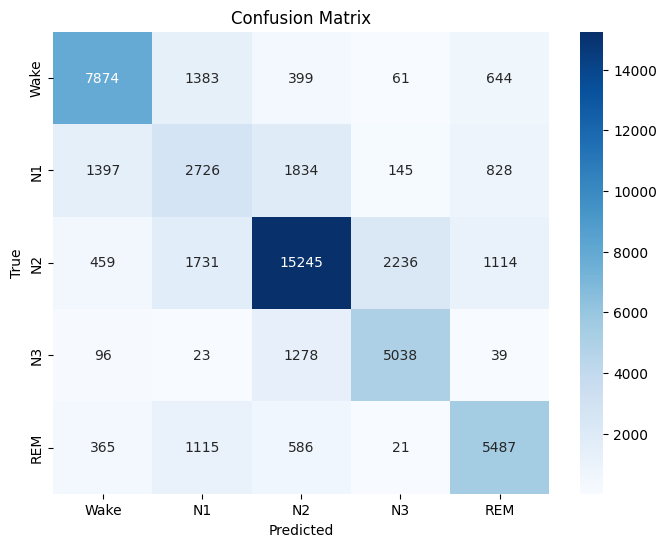

In [ ]:
lgb_relieff_enhanced = lgb.LGBMClassifier(
    n_estimators=500, # trees
    learning_rate=0.05,
    max_depth=10,
    num_leaves=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb_relieff_enhanced = model_fct.train_model(lgb_relieff_enhanced, X_train_relieff_norm_enhanced, y_train_norm_enhanced, X_val_relieff_norm_enhanced)

df_eval = model_fct.create_evaluation_table(y_val_norm_enhanced, y_pred_lgb_relieff_enhanced,df_val)

model_fct.evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## XGBoost + Lag/ Lead

Train time: 467.42 seconds

Accuracy 0.7218

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.80      0.82      0.81     10361
          N1       0.41      0.41      0.41      6930
          N2       0.82      0.73      0.77     20785
          N3       0.69      0.86      0.77      6474
         REM       0.70      0.73      0.71      7574

    accuracy                           0.72     52124
   macro avg       0.68      0.71      0.69     52124
weighted avg       0.73      0.72      0.72     52124



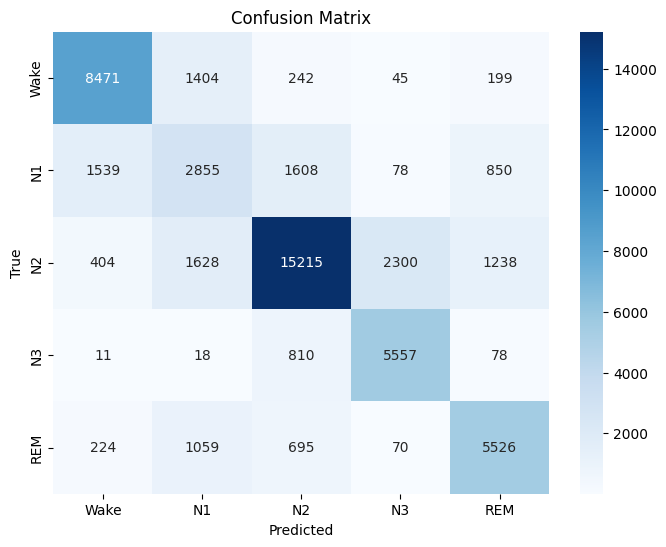

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_norm_basic)

xgb_lag = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

y_pred_xgb_lag = model_fct.train_model(
    xgb_lag, X_train_raw_basic, y_train_raw_basic, X_val_raw_basic, sample_weights
    )

df_eval = model_fct.create_evaluation_table(y_val_raw_basic, y_pred_xgb_lag,df_val)
model_fct.evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## XGBoost + Advance Temporal Context

Train time: 958.81 seconds

Accuracy 0.7241

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.80      0.81     10361
          N1       0.42      0.41      0.42      6930
          N2       0.80      0.76      0.78     20785
          N3       0.69      0.81      0.74      6474
         REM       0.72      0.75      0.73      7574

    accuracy                           0.72     52124
   macro avg       0.69      0.70      0.70     52124
weighted avg       0.73      0.72      0.72     52124



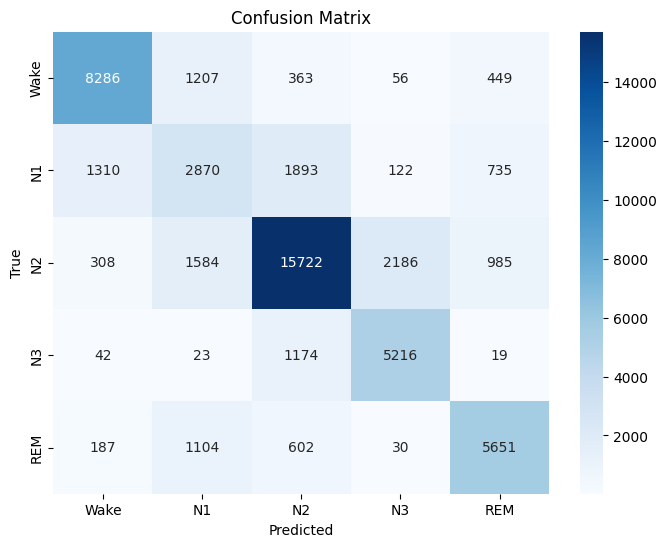

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_norm_basic)

xgb_norm_enhanced = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

y_pred_xgb_norm_enhanced = model_fct.train_model(
    xgb_norm_enhanced, X_train_norm_enhanced, y_train_norm_enhanced, X_val_norm_enhanced, sample_weights
    )

df_eval = model_fct.create_evaluation_table(y_val_raw_basic, y_pred_xgb_norm_enhanced,df_val)

model_fct.evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## XGBoost + ReliefF

Train time: 134.67 seconds

Accuracy 0.6957

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.75      0.77     10361
          N1       0.40      0.41      0.41      6930
          N2       0.80      0.72      0.75     20785
          N3       0.65      0.80      0.72      6474
         REM       0.67      0.73      0.70      7574

    accuracy                           0.70     52124
   macro avg       0.66      0.68      0.67     52124
weighted avg       0.70      0.70      0.70     52124



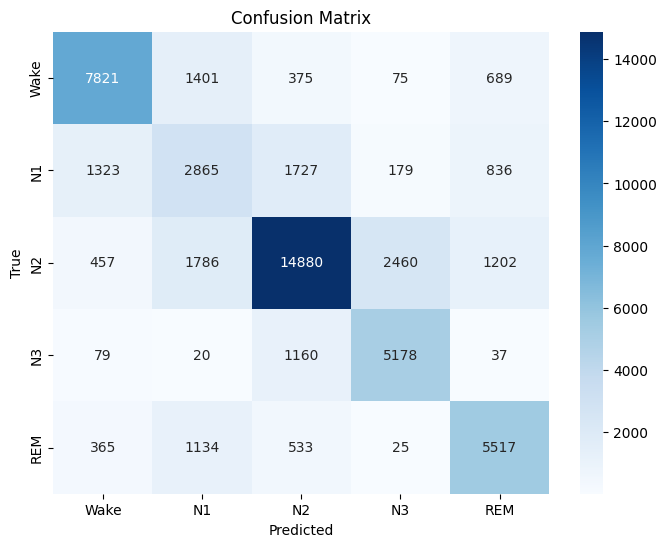

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_norm_basic)

xgb_relieff_enhanced = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

y_pred_xgb_relieff_enhanced = model_fct.train_model(
    xgb_relieff_enhanced, X_train_relieff_norm_enhanced, y_train_norm_enhanced, X_val_relieff_norm_enhanced, sample_weights
    )

df_eval = model_fct.create_evaluation_table(y_val_raw_basic, y_pred_xgb_relieff_enhanced,df_val)

model_fct.evaluete_model(df_eval['Label'], df_eval['Pred_Smooth'])

## Random Forest with Temporal Context

Train time: 732.34 seconds

Accuracy 0.7089

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.74      0.80      0.77     10361
          N1       0.47      0.21      0.29      6930
          N2       0.73      0.83      0.78     20785
          N3       0.75      0.71      0.73      6474
         REM       0.66      0.71      0.68      7574

    accuracy                           0.71     52124
   macro avg       0.67      0.65      0.65     52124
weighted avg       0.69      0.71      0.69     52124



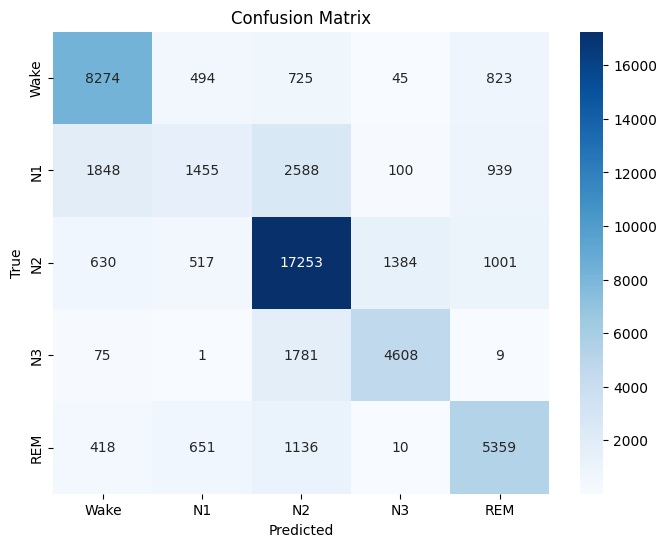

In [ ]:
rf_norm_enhanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_rf_pred_norm_enhanced = model_fct.train_model(rf_norm_enhanced, X_train_norm_enhanced, y_train_norm_enhanced, X_val_norm_enhanced)

model_fct.evaluete_model(y_val_norm_enhanced, y_rf_pred_norm_enhanced)

## RF Divide et Impera

Train time: 1166.07 seconds
Accuracy 0.6980

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.84      0.66      0.74     10361
          N1       0.44      0.27      0.33      6930
          N2       0.69      0.87      0.77     20785
          N3       0.78      0.67      0.72      6474
         REM       0.67      0.69      0.68      7574

    accuracy                           0.70     52124
   macro avg       0.68      0.63      0.65     52124
weighted avg       0.69      0.70      0.69     52124



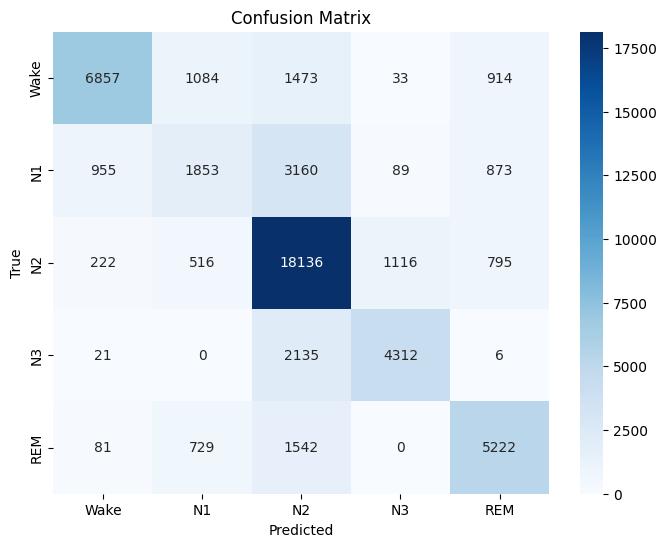

In [ ]:
start_time = time.time()

# Sleep vs wake
y_train_bin = y_train_norm_enhanced.apply(lambda x: 0 if x == 0 else 1)
rf_binary = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_binary.fit(X_train_norm_enhanced, y_train_bin)

# Only sleep stages
mask_sleep = y_train_norm_enhanced != 0
X_train_sleep = X_train_norm_enhanced[mask_sleep]
y_train_sleep = y_train_norm_enhanced[mask_sleep]

rf_sleep = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_sleep.fit(X_train_sleep, y_train_sleep)

# Combine
preds_bin = rf_binary.predict(X_val_norm_enhanced)
preds_sleep = rf_sleep.predict(X_val_norm_enhanced)
y_pred_ierarhic = np.where(preds_bin == 0, 0, preds_sleep)

print(f"Train time: {round((time.time() - start_time), 2)} seconds")
model_fct.evaluete_model(y_val_norm_enhanced, y_pred_ierarhic)

# Cross-validation & Feature Importance for the best models

In [ ]:
def get_tree_importance(model, feature_names, model_name):
    """Extrage importanța pentru Random Forest, LightGBM, XGBoost"""
    importances = model.feature_importances_

    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    df_imp = df_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=df_imp.head(15), x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)

    plt.title(f'Top 15 Feature Importances - {model_name}', fontsize=16)
    plt.xlabel('Gini / Split', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

    return df_imp

In [ ]:
X_full_norm_basic = pd.concat([X_train_norm_basic, X_val_norm_basic], ignore_index=True)
y_full_norm_basic = pd.concat([y_train_norm_basic, y_val_norm_basic], ignore_index=True)

X_full_norm_enhanced = pd.concat([X_train_norm_enhanced, X_val_norm_enhanced], ignore_index=True)
y_full_norm_enhanced = pd.concat([y_train_norm_enhanced, y_val_norm_enhanced], ignore_index=True)

## LightGBM + Zscore

In [ ]:
lgb_zscore = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


best_lgb, mean_acc_lgb = model_fct.cross_validation_model(
    model=lgb_zscore,
    X=X_full_norm_basic,
    y=y_full_norm_basic,
    model_name="LightGBM_Zscore",
    save_path='./models'
)

=== Cross validation for LightGBM_Zscore (5 folds) ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.260652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24228
[LightGBM] [Info] Number of data points in the train set: 224269, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: Accuracy = 0.8051 -> New best!

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.263691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24228
[LightGBM] [Info] Number of data points in the train set: 224269, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: Accuracy = 0.8067 -> New best!

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.260010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24228
[LightGBM] [Info] Number of data points in the train set: 224270, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


...

Fold 3: Accuracy = 0.8056

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.294855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24228
[LightGBM] [Info] Number of data points in the train set: 224270, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: Accuracy = 0.8020

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.437166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24228
[LightGBM] [Info] Number of data points in the train set: 224270, number of used features: 96
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: Accuracy = 0.8039


Final results LightGBM_Zscore:
Mean accuracy: 0.8047 (± 0.0016)
Best model save at: ./models/best_LightGBM_Zscore_model.pkl



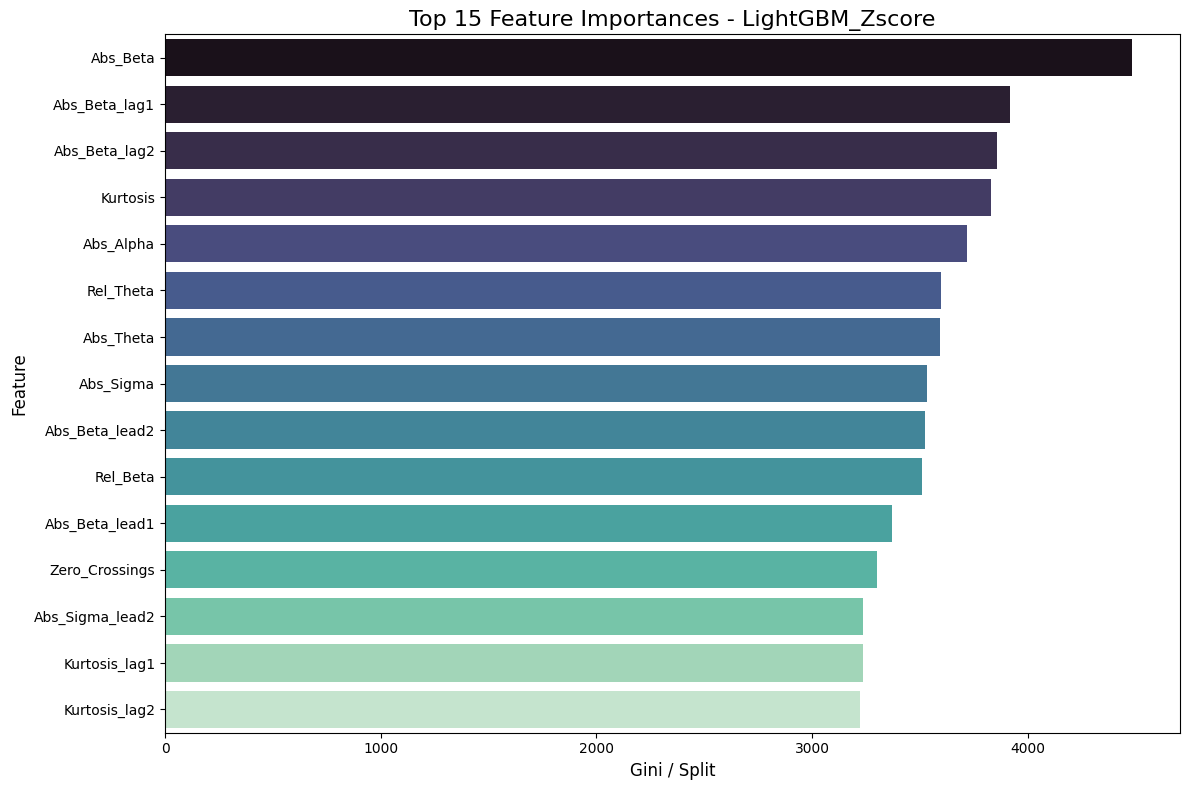

In [ ]:
df_importance_lgb = get_tree_importance(
    model=best_lgb,
    feature_names=X_full_norm_basic.columns,
    model_name="LightGBM_Zscore"
)

## LightGBM + Temp Context

In [ ]:
lgb_norm_enhanced = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_lgb_enh, mean_acc_lgb__enh = model_fct.cross_validation_model(
    model=lgb_norm_enhanced,
    X=X_full_norm_enhanced,
    y=y_full_norm_enhanced,
    model_name="LightGBM_Temporal_Context",
    save_path='./models'
)

=== Cross validation for LightGBM_Temporal_Context (5 folds) ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.512851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42840
[LightGBM] [Info] Number of data points in the train set: 224269, number of used features: 168
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: Accuracy = 0.8091 -> New best!

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.524568 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42840
[LightGBM] [Info] Number of data points in the train set: 224269, number of used features: 168
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: Accuracy = 0.8104 -> New best!

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.630394 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42840
[LightGBM] [Info] Number of data points in the train set: 224270, number of used features: 168
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


...

Fold 3: Accuracy = 0.8106 -> New best!

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.897020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42840
[LightGBM] [Info] Number of data points in the train set: 224270, number of used features: 168
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: Accuracy = 0.8079

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.837466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42840
[LightGBM] [Info] Number of data points in the train set: 224270, number of used features: 168
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: Accuracy = 0.8096


Final results LightGBM_Temporal_Context:
Mean accuracy: 0.8095 (± 0.0010)
Best model save at: ./models/best_LightGBM_Temporal_Context_model.pkl



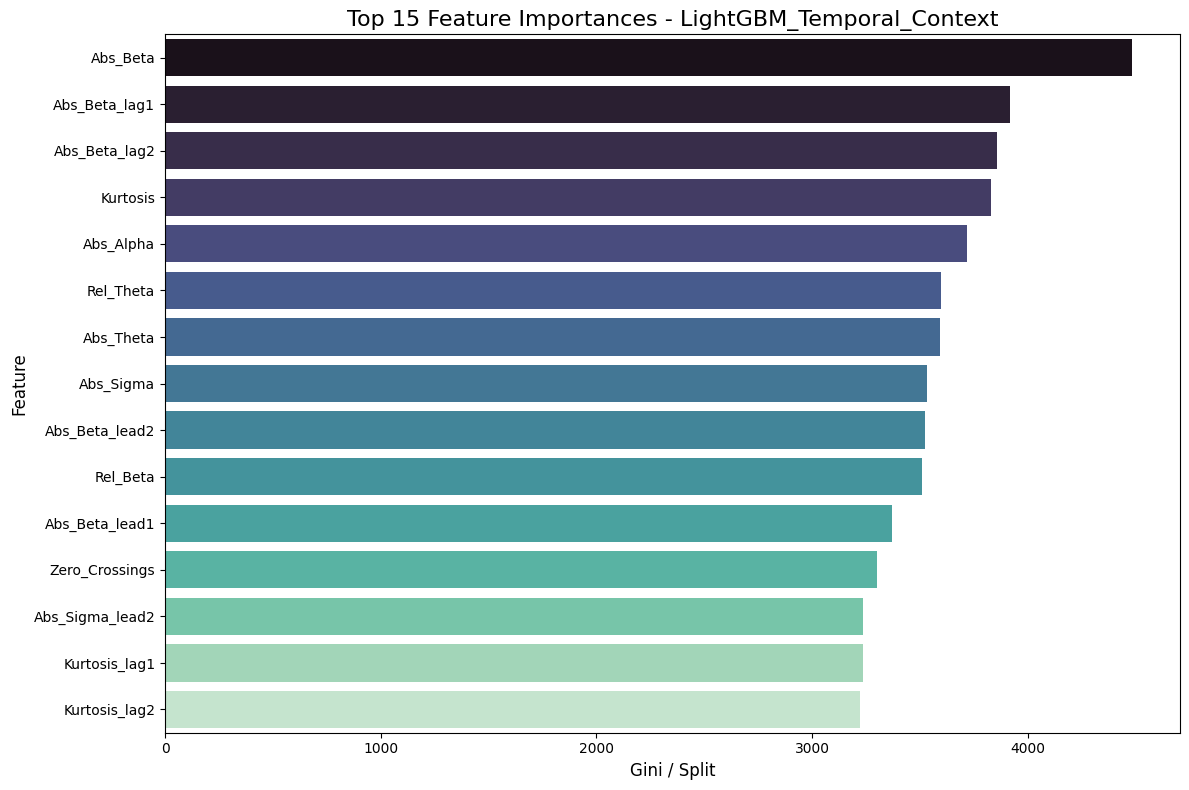

In [ ]:
df_importance_lgb = get_tree_importance(
    model=best_lgb,
    feature_names=X_full_norm_basic.columns,
    model_name="LightGBM_Temporal_Context"
)

## XGBoost

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_full_norm_enhanced)

xgb_norm_enhanced = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

best_xgboost, mean_acc_xbg = model_fct.cross_validation_model(
    model=xgb_norm_enhanced,
    X=X_full_norm_enhanced,
    y=y_full_norm_enhanced,
    model_name="XGBoost_TempFeatures",
    save_path=base_path + './models',
    sample_weights = sample_weights
)

=== Cross validation for XGBoost_TempFeatures (5 folds) ===
Fold 1: Accuracy = 0.7993 -> New best!

Fold 2: Accuracy = 0.8010 -> New best!



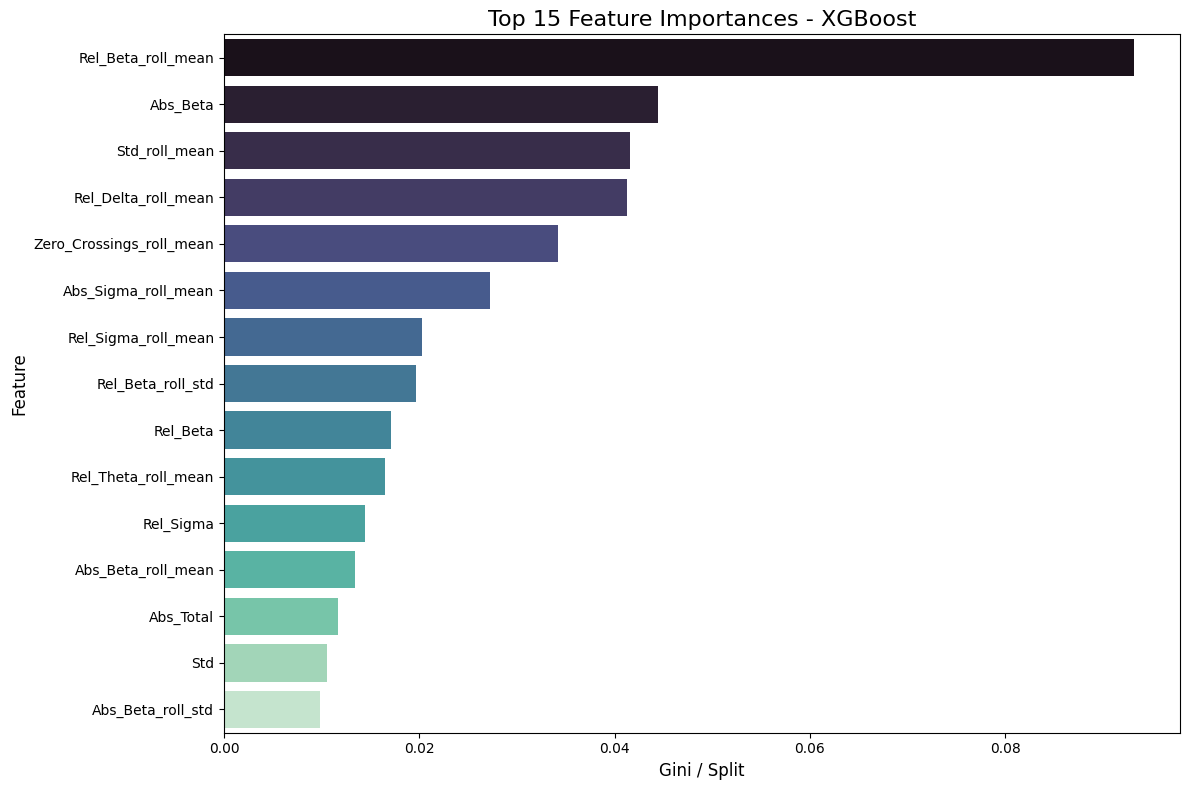

In [ ]:
df_importance_xgb = get_tree_importance(
    model=best_xgboost,
    feature_names=X_full_norm_enhanced.columns,
    model_name="XGBoost"
)

## Random Forest

In [ ]:
rf_norm_enhanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_rf, mean_acc_rf = model_fct.cross_validation_model(
    model=rf_norm_enhanced,
    X=X_full_norm_enhanced,
    y=y_full_norm_enhanced,
    model_name="RandomForest_TempFeatures",
    save_path=base_path + '/models'
)

=== Cross validation for RandomForest_TempFeatures (5 folds) ===
Fold 1: Accuracy = 0.7640 -> New best!

Fold 2: Accuracy = 0.7678 -> New best!

Fold 3: Accuracy = 0.7675

Fold 4: Accuracy = 0.7660

Fold 5: Accuracy = 0.7668


Final results RandomForest_TempFeatures:
Mean accuracy: 0.7664 (± 0.0014)
Best model save at: /content/drive/MyDrive/sleep_data/models/best_RandomForest_TempFeatures_model.pkl



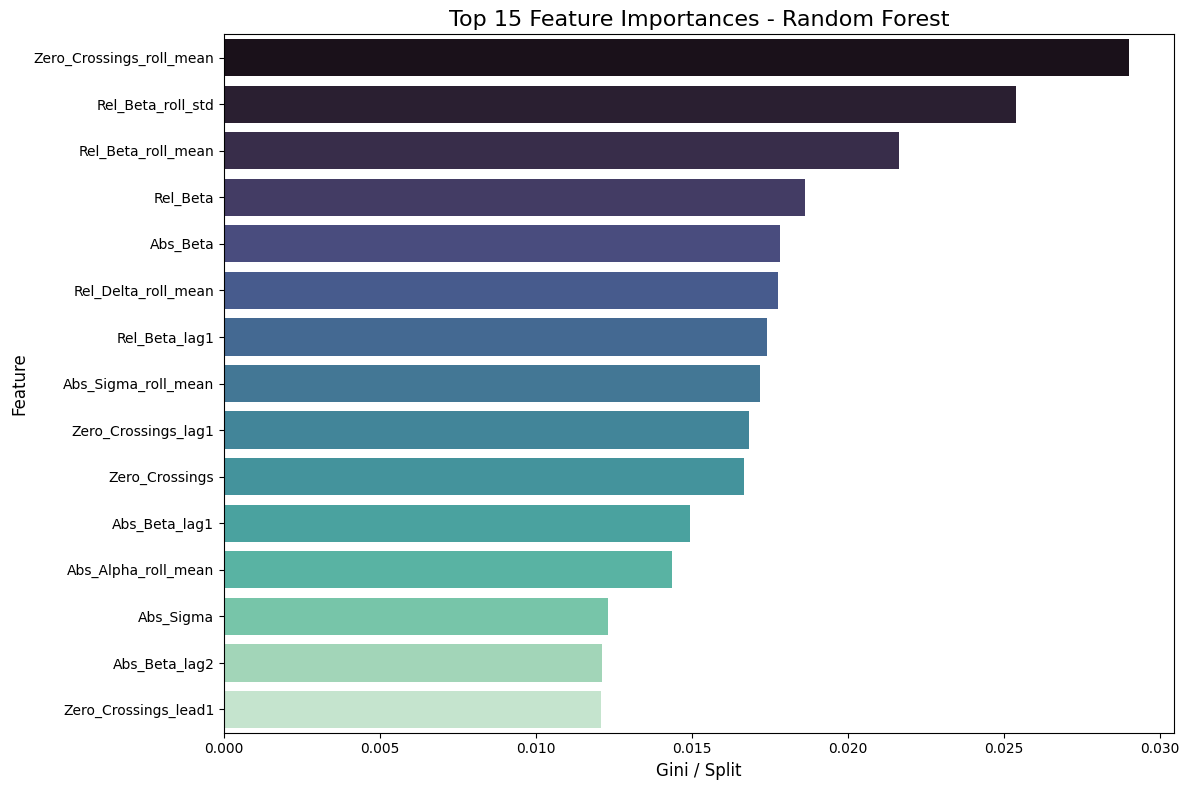

In [ ]:
df_importance_rf = get_tree_importance(
    model=best_rf,
    feature_names=X_full_norm_enhanced.columns,
    model_name="Random Forest"
)

# Conclusion

The best variants of the dataset were those where we added a lot of temporal context on top of a Z-Score normalization **per patient**. For this extraction we extracted:
* Ratios to assess deep sleep and sleep transition phases
* _lag1, _lag2, _lead1, _lead2 the previous and future values ​​of each feature (for temporal context)
* _diff the difference between present and _lag1
* _roll_mean, _roll_std - mean and variance over present and the 4 lags and lead

Our best model is **LightGMB with Temporal Context** with an average accuracy of 0.8096.